In [7]:
# 1. IMPORTACION DE LIBRERIAS
# ---------------------------------------------------------------------------
import pandas as pd                                  # Manejo de datos tabulares (DataFrames)
import numpy as np                                    # Operaciones numericas y arreglos
import matplotlib.pyplot as plt                        # Generacion de graficos
import matplotlib.ticker as mticker                    # Formato de ejes en graficos
 
from sklearn.model_selection import train_test_split    # Division train/test
from sklearn.preprocessing import StandardScaler        # Escalado de variables (necesario para NN y SVM)
from sklearn.tree import DecisionTreeRegressor           # Modelo 1: Arbol de Decision
from sklearn.neural_network import MLPRegressor          # Modelo 2: Red Neuronal (Perceptron Multicapa)
from sklearn.svm import SVR                               # Modelo 3: Support Vector Regression (SVM)
from sklearn.metrics import (                              # Metricas de evaluacion de regresion
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)
from src.features.prepare_model_data import prepare_model_data


 

In [6]:
import sys
from pathlib import Path

# Sube dos niveles: Modeling -> src -> Grupo8_Air_Quality_MLOps
project_root = Path.cwd().parent.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Raíz del proyecto agregada:", project_root)

Raíz del proyecto agregada: d:\Ciencia de Datos\06 Proyecto Integrador\Leccion 12\Proyecto final\Grupo8_Air_Quality_MLOps


In [8]:
# Semilla fija para que los resultados sean reproducibles cada vez que se corre el script
RANDOM_STATE = 42

In [9]:

df = prepare_model_data()

Data Cleaning completado correctamente.
Filas originales: 9471
Filas después de limpieza: 9357
Filas eliminadas: 114
Columnas: 16
Feature Engineering completado correctamente.
Filas: 9357
Columnas: 28
Dataset de modelado preparado correctamente.
Filas originales: 9357
Filas finales: 8224
Filas excluidas: 1133
Features predictivas: 12
Target: target_next_hour
Cobertura final: 87.89 %


In [10]:
# 3. DEFINICION DE VARIABLES PREDICTORAS (X) Y VARIABLE OBJETIVO (y)
# ---------------------------------------------------------------------------
# La variable objetivo (target) es 'target_next_hour': concentracion de
# C6H6_GT proyectada una hora hacia el futuro.
COLUMNA_TARGET = "target_next_hour"
 
# Se excluyen 'timestamp' (no es una variable numerica utilizable directamente)
# y 'target_next_hour' (es la variable que queremos predecir, no puede ser feature)
COLUMNAS_EXCLUIDAS = ["timestamp", COLUMNA_TARGET]
 
# Lista de columnas que SI se usaran como variables predictoras (features)
columnas_features = [c for c in df.columns if c not in COLUMNAS_EXCLUIDAS]
print("\nFeatures utilizadas para el modelo:", columnas_features)
 
# Matriz de variables predictoras (features)
X = df[columnas_features].copy()
 
# Vector de la variable objetivo (lo que se quiere predecir)
y = df[COLUMNA_TARGET].copy()
 


Features utilizadas para el modelo: ['C6H6_GT', 'hour', 'day_of_week', 'month', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168', 'rolling_mean_3', 'rolling_mean_24', 'rolling_std_24']


In [11]:
# 4. DIVISION EN CONJUNTO DE ENTRENAMIENTO Y PRUEBA
# ---------------------------------------------------------------------------
# Como es una serie de tiempo, NO se debe mezclar aleatoriamente (shuffle=False):
# se entrena con el pasado y se prueba con el futuro, tal como ocurriria en un
# escenario real de prediccion.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% de los datos (los mas recientes) para prueba
    shuffle=False,        # Se respeta el orden cronologico, no se mezcla
)
 
print(f"\nRegistros de entrenamiento: {len(X_train)}")
print(f"Registros de prueba: {len(X_test)}")
 


Registros de entrenamiento: 6579
Registros de prueba: 1645


In [12]:
# 5. ESCALADO DE VARIABLES
# ---------------------------------------------------------------------------
# Los Arboles de Decision no requieren escalado (son invariantes a la escala),
# pero SVM y Redes Neuronales SI son sensibles a la escala de los datos, por lo
# que se estandarizan (media 0, desviacion estandar 1) usando SOLO los datos
# de entrenamiento (para evitar fuga de informacion / data leakage).
escalador_X = StandardScaler()                          # Escalador para las features
X_train_esc = escalador_X.fit_transform(X_train)          # Se ajusta y transforma el train
X_test_esc = escalador_X.transform(X_test)                 # Se transforma el test con el mismo ajuste
 
# La variable objetivo tambien se escala para SVM y NN, ya que ambos modelos
# convergen mejor y son mas estables cuando el target esta en una escala similar
escalador_y = StandardScaler()
y_train_esc = escalador_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_esc = escalador_y.transform(y_test.values.reshape(-1, 1)).ravel()
 

In [13]:
# 6. ENTRENAMIENTO DE LOS MODELOS
# ---------------------------------------------------------------------------
 
# --- Modelo 1: Arbol de Decision ---------------------------------------
# Usa los datos SIN escalar, ya que los arboles dividen por umbrales y no
# les afecta la escala de las variables.
modelo_arbol = DecisionTreeRegressor(
    max_depth=8,                 # Profundidad maxima para evitar sobreajuste
    min_samples_leaf=5,          # Minimo de muestras por hoja, tambien contra sobreajuste
    random_state=RANDOM_STATE,   # Reproducibilidad
)
modelo_arbol.fit(X_train, y_train)                       # Entrenamiento con datos originales
pred_arbol = modelo_arbol.predict(X_test)                 # Prediccion sobre el conjunto de prueba
 
# --- Modelo 2: Red Neuronal (MLPRegressor) ------------------------------
# Se usan los datos escalados (features y target), ya que las redes neuronales
# convergen mejor y mas rapido con variables normalizadas.
modelo_red = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # Dos capas ocultas: 64 y 32 neuronas
    activation="relu",            # Funcion de activacion ReLU (estandar para regresion)
    solver="adam",                # Optimizador Adam (eficiente para datasets medianos/grandes)
    max_iter=2000,                 # Maximo de iteraciones de entrenamiento
    early_stopping=True,          # Detiene el entrenamiento si deja de mejorar (evita sobreajuste)
    random_state=RANDOM_STATE,    # Reproducibilidad
)
modelo_red.fit(X_train_esc, y_train_esc)                  # Entrenamiento con datos escalados
pred_red_esc = modelo_red.predict(X_test_esc)               # Prediccion en escala normalizada
# Se revierte la escala de la prediccion para volver a las unidades originales de C6H6_GT
pred_red = escalador_y.inverse_transform(pred_red_esc.reshape(-1, 1)).ravel()
 
# --- Modelo 3: SVM (Support Vector Regression) --------------------------
# Tambien requiere datos escalados por su sensibilidad a la escala de las variables.
modelo_svm = SVR(
    kernel="rbf",     # Kernel radial (RBF), captura relaciones no lineales
    C=10,             # Parametro de regularizacion (mayor C = menos regularizacion)
    epsilon=0.05,     # Margen de tolerancia sin penalizacion
    gamma="scale",    # Ajuste automatico del parametro gamma segun los datos
)
modelo_svm.fit(X_train_esc, y_train_esc)                    # Entrenamiento con datos escalados
pred_svm_esc = modelo_svm.predict(X_test_esc)                 # Prediccion en escala normalizada
# Se revierte la escala para obtener la prediccion en unidades originales
pred_svm = escalador_y.inverse_transform(pred_svm_esc.reshape(-1, 1)).ravel()

In [14]:
# 7. CALCULO DE METRICAS (RMSE, MAE, R2) PARA CADA MODELO
# ---------------------------------------------------------------------------
def calcular_metricas(y_real, y_pred):
    """Calcula RMSE, MAE y R2 dado un vector real y uno predicho."""
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))    # Raiz del error cuadratico medio
    mae = mean_absolute_error(y_real, y_pred)               # Error absoluto medio
    r2 = r2_score(y_real, y_pred)                             # Coeficiente de determinacion
    return rmse, mae, r2
 
# Se calculan las metricas de cada modelo sobre el conjunto de prueba (y_test, en unidades originales)
rmse_arbol, mae_arbol, r2_arbol = calcular_metricas(y_test, pred_arbol)
rmse_red, mae_red, r2_red = calcular_metricas(y_test, pred_red)
rmse_svm, mae_svm, r2_svm = calcular_metricas(y_test, pred_svm)
 
# Se organiza todo en un DataFrame para comparar los modelos facilmente
resultados = pd.DataFrame({
    "Modelo": ["Arbol de Decision", "Red Neuronal (MLP)", "SVM (SVR)"],
    "RMSE": [rmse_arbol, rmse_red, rmse_svm],
    "MAE": [mae_arbol, mae_red, mae_svm],
    "R2": [r2_arbol, r2_red, r2_svm],
})
 
# Se ordena de mejor a peor segun RMSE (menor es mejor)
resultados = resultados.sort_values("RMSE").reset_index(drop=True)
print("\n=== COMPARACION DE MODELOS ===")
print(resultados.to_string(index=False))
 
 
# Se identifica el mejor modelo (menor RMSE) para resaltarlo en los graficos
mejor_modelo_nombre = resultados.iloc[0]["Modelo"]
print(f"\nMejor modelo segun RMSE: {mejor_modelo_nombre}")


=== COMPARACION DE MODELOS ===
            Modelo     RMSE      MAE       R2
Red Neuronal (MLP) 3.022719 2.032896 0.790221
 Arbol de Decision 3.148903 1.967621 0.772341
         SVM (SVR) 3.158128 2.060172 0.771005

Mejor modelo segun RMSE: Red Neuronal (MLP)


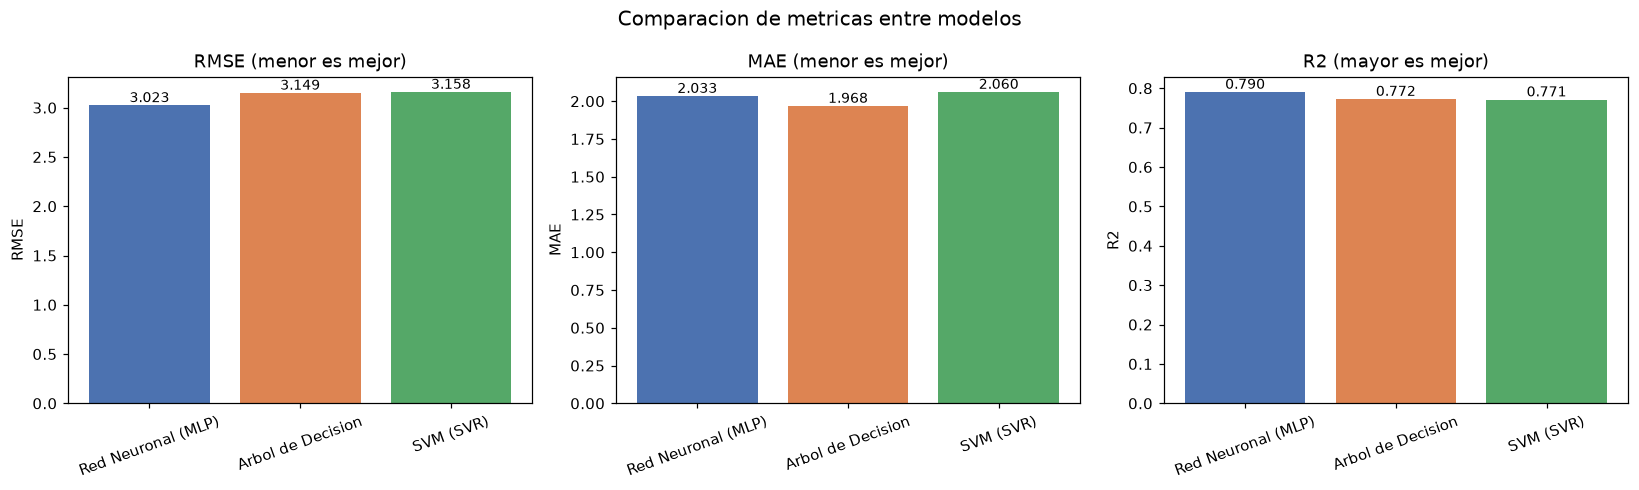

In [16]:
# 8. GRAFICOS
# ---------------------------------------------------------------------------
plt.rcParams["figure.dpi"] = 110                          # Resolucion de los graficos
 
# --- Grafico 1: Comparacion de metricas entre modelos (barras) ----------
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5))           # Tres subgraficos: RMSE, MAE, R2
colores = ["#4C72B0", "#DD8452", "#55A868"]                   # Un color por modelo
 
for eje, metrica, titulo in zip(
    ejes, ["RMSE", "MAE", "R2"], ["RMSE (menor es mejor)", "MAE (menor es mejor)", "R2 (mayor es mejor)"]
):
    eje.bar(resultados["Modelo"], resultados[metrica], color=colores)  # Barra por modelo
    eje.set_title(titulo)                                               # Titulo del subgrafico
    eje.set_ylabel(metrica)                                              # Etiqueta del eje Y
    eje.tick_params(axis="x", rotation=20)                                # Rotar nombres de modelos
    for i, valor in enumerate(resultados[metrica]):                        # Anotar el valor sobre cada barra
        eje.text(i, valor, f"{valor:.3f}", ha="center", va="bottom", fontsize=9)
 
plt.suptitle("Comparacion de metricas entre modelos", fontsize=13)
plt.tight_layout()
plt.show()
 